In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'grad-cam', '-q'])

✅ grad-cam installed


In [3]:
import json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from PIL import Image
from pathlib import Path
import base64, io

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import timm

# Grad-CAM methods 
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


PROJECT_ROOT    = Path(r"D:\rural diagnosis\rural_health_ai")
BEST_MODEL_PATH = PROJECT_ROOT / 'models' / 'checkpoints' / 'best_model.pth'
GRADCAM_DIR     = PROJECT_ROOT / 'outputs' / 'gradcam'
GRADCAM_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda')

# LOAD CONFIG 
with open(PROJECT_ROOT / 'data' / 'config.json') as f:
    cfg = json.load(f)
with open(PROJECT_ROOT / 'data' / 'class_info.json', encoding='utf-8') as f:
    class_info = json.load(f)['class_info']

CLASS_TO_IDX = cfg['class_to_idx']
IDX_TO_CLASS = {int(k): v for k, v in cfg['idx_to_class'].items()}
NUM_CLASSES  = cfg['num_classes']

#LOAD MODEL
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device,weights_only=False)
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=7)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f'   Classes: {list(CLASS_TO_IDX.keys())}')

✅ Model loaded — epoch 15, val acc 74.83%
   Device: cuda
   Classes: ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']


In [4]:
# EfficientNet-B0 architecture in timm:
# model.conv_stem → model.blocks[0..6] → model.conv_head → model.classifier
#
# Best Grad-CAM layer = last block = model.blocks[-1]
# This gives the richest spatial feature map before global pooling

target_layers = [model.blocks[-1]]

print('Target layer for Grad-CAM:')
print(f'  {target_layers[0].__class__.__name__}')
print()

# Verify by checking output shape with a dummy input
dummy = torch.randn(1, 3, 224, 224).to(device)
with torch.no_grad():
    out = model(dummy)
print(f'Model output shape: {out.shape}')  # should be [1, 7]
print(f'Softmax probs sum : {out.softmax(1).sum().item():.4f}')  # should be 1.0
print()

Target layer for Grad-CAM:
  Sequential

Model output shape: torch.Size([1, 7])
Softmax probs sum : 1.0000

✅ Layer verified — ready for Grad-CAM


In [5]:
# ── PREPROCESSING ──────────────────────────────────────────
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(cfg['imagenet_mean'], cfg['imagenet_std']),
])

def denormalise_for_display(tensor):
    """Reverse ImageNet normalisation → numpy float32 [0,1] for display."""
    mean = torch.tensor(cfg['imagenet_mean']).view(3,1,1)
    std  = torch.tensor(cfg['imagenet_std']).view(3,1,1)
    img  = (tensor.cpu() * std + mean).clamp(0, 1)
    return img.permute(1,2,0).numpy().astype(np.float32)


def predict_and_gradcam(image_input, cam_method='gradcam++', target_class=None):
    """
    Full pipeline: image → top-3 predictions + Grad-CAM heatmap overlay.

    Args:
        image_input  : PIL Image, file path string, or bytes
        cam_method   : 'gradcam' | 'gradcam++' | 'eigencam'
        target_class : int or None. If None, uses predicted class.

    Returns dict:
        {
          'top3'          : [{class, label, hindi, confidence, severity}, ...],
          'predicted_idx' : int,
          'predicted_cls' : str,
          'confidence'    : float  (0-100),
          'severity'      : str    ('LOW'/'MEDIUM'/'HIGH'),
          'next_step'     : str    (Hindi),
          'uncertain'     : bool   (True if confidence < 60%),
          'heatmap_rgb'   : np.ndarray  float32 [0,1] shape (224,224,3),
          'original_rgb'  : np.ndarray  float32 [0,1] shape (224,224,3),
          'heatmap_b64'   : str    (base64 PNG — ready for API response),
        }
    """
    # ── Load image ──
    if isinstance(image_input, (str, Path)):
        pil_img = Image.open(image_input).convert('RGB')
    elif isinstance(image_input, bytes):
        pil_img = Image.open(io.BytesIO(image_input)).convert('RGB')
    elif isinstance(image_input, Image.Image):
        pil_img = image_input.convert('RGB')
    else:
        raise ValueError('image_input must be path, bytes, or PIL Image')

    # ── Preprocess ──
    input_tensor = preprocess(pil_img).unsqueeze(0).to(device)  # [1,3,224,224]
    rgb_img      = denormalise_for_display(input_tensor.squeeze(0))

    # ── Inference ──
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)            # [1 , 7]
        probs  = logits.softmax(dim=1)[0]       # [7]

    # Top-3 predictions
    top3_vals, top3_idxs = probs.topk(3)
    top3 = []
    for val, idx in zip(top3_vals.cpu().numpy(), top3_idxs.cpu().numpy()):
        cls  = IDX_TO_CLASS[int(idx)]
        info = class_info[cls]
        top3.append({
            'class'      : cls,
            'label'      : info['full'],
            'hindi'      : info['hindi'],
            'confidence' : round(float(val) * 100, 1),
            'severity'   : info['severity'],
        })

    predicted_idx = int(top3_idxs[0].cpu())
    predicted_cls = IDX_TO_CLASS[predicted_idx]
    confidence    = top3[0]['confidence']
    uncertain     = confidence < 60.0

    # ── Grad-CAM ──
    cam_target = [ClassifierOutputTarget(
        target_class if target_class is not None else predicted_idx
    )]

    CAM_METHODS = {
        'gradcam'  : GradCAM,
        'gradcam++': GradCAMPlusPlus,
        'eigencam' : EigenCAM,
    }
    CAMClass = CAM_METHODS.get(cam_method, GradCAMPlusPlus)

    with CAMClass(model=model, target_layers=target_layers) as cam:
        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=cam_target,
            aug_smooth=True,      # average over augmented versions — smoother maps
            eigen_smooth=True,    # PCA smoothing — reduces noise
        )[0]                      # shape (224, 224)

    # Overlay heatmap on original image
    heatmap_rgb = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True,
        colormap=cv2.COLORMAP_JET,
        image_weight=0.5,   # 50% original, 50% heatmap
    )
    heatmap_rgb = heatmap_rgb.astype(np.float32) / 255.0

    # Convert to base64 PNG for API
    heatmap_pil = Image.fromarray((heatmap_rgb * 255).astype(np.uint8))
    buf = io.BytesIO()
    heatmap_pil.save(buf, format='PNG')
    heatmap_b64 = base64.b64encode(buf.getvalue()).decode('utf-8')

    return {
        'top3'          : top3,
        'predicted_idx' : predicted_idx,
        'predicted_cls' : predicted_cls,
        'confidence'    : confidence,
        'severity'      : class_info[predicted_cls]['severity'],
        'next_step'     : class_info[predicted_cls]['next_step'],
        'uncertain'     : uncertain,
        'heatmap_rgb'   : heatmap_rgb,
        'original_rgb'  : rgb_img,
        'heatmap_b64'   : heatmap_b64,
    }


✅ predict_and_gradcam() function defined
   Inputs : PIL Image | file path | bytes
   Returns: top3 predictions + heatmap overlay + base64 PNG


Testing on: ISIC_0029704.jpg
True class: nv (Melanocytic Nevi)

Top-3 predictions:
  → [1] mel     62.3%  HIGH    Melanoma
     [2] nv      37.5%  LOW     Melanocytic Nevi
     [3] bkl      0.1%  LOW     Benign Keratosis

Uncertain     : False (threshold: 60%)
Next step     : तुरंत जिला अस्पताल रेफर करें। देरी खतरनाक हो सकती है।
Heatmap b64   : iVBORw0KGgoAAAANSUhEUgAAAOAAAADgCAIAAACV... (81584 chars)



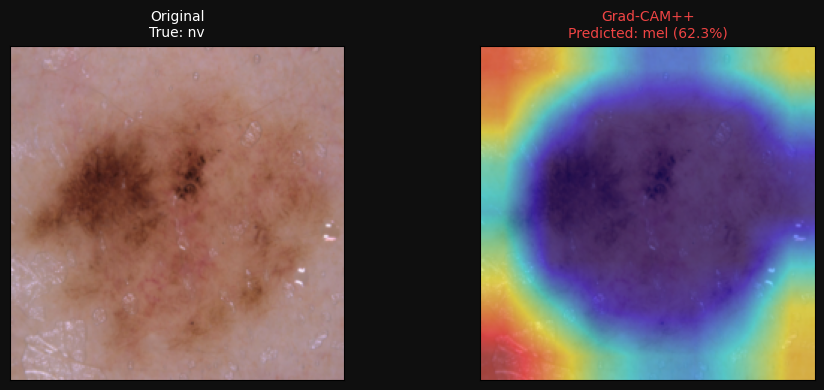

✅ Smoke test passed — Grad-CAM working


In [6]:
# Grab any one image from the test set
test_df   = pd.read_csv(PROJECT_ROOT / 'data' / 'test_split.csv')
sample_row = test_df.iloc[0]
sample_path = sample_row['img_path']
true_class  = IDX_TO_CLASS[int(sample_row['label'])]

print(f'Testing on: {Path(sample_path).name}')
print(f'True class: {true_class} ({class_info[true_class]["full"]})')
print()

# Run full pipeline
result = predict_and_gradcam(sample_path, cam_method='gradcam++')

# Print predictions
print('Top-3 predictions:')
for i, pred in enumerate(result['top3']):
    marker = '→' if i == 0 else '  '
    print(f'  {marker} [{i+1}] {pred["class"]:6s} {pred["confidence"]:5.1f}%  '
          f'{pred["severity"]:6s}  {pred["label"]}')

print(f'\nUncertain     : {result["uncertain"]} (threshold: 60%)')
print(f'Next step     : {result["next_step"]}')
print(f'Heatmap b64   : {result["heatmap_b64"][:40]}... ({len(result["heatmap_b64"])} chars)')
print()

# Quick display
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.patch.set_facecolor('#0f0f0f')
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_facecolor('#0f0f0f')

axes[0].imshow(result['original_rgb'])
axes[0].set_title(f'Original\nTrue: {true_class}', color='white', fontsize=10)

axes[1].imshow(result['heatmap_rgb'])
axes[1].set_title(
    f'Grad-CAM++\nPredicted: {result["predicted_cls"]} ({result["confidence"]:.1f}%)',
    color='#22c55e' if result['predicted_cls'] == true_class else '#ef4444',
    fontsize=10
)

plt.tight_layout()
plt.savefig(GRADCAM_DIR / 'smoke_test.png', dpi=120,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()


Comparing CAM methods on: ISIC_0030211.jpg (class: mel)


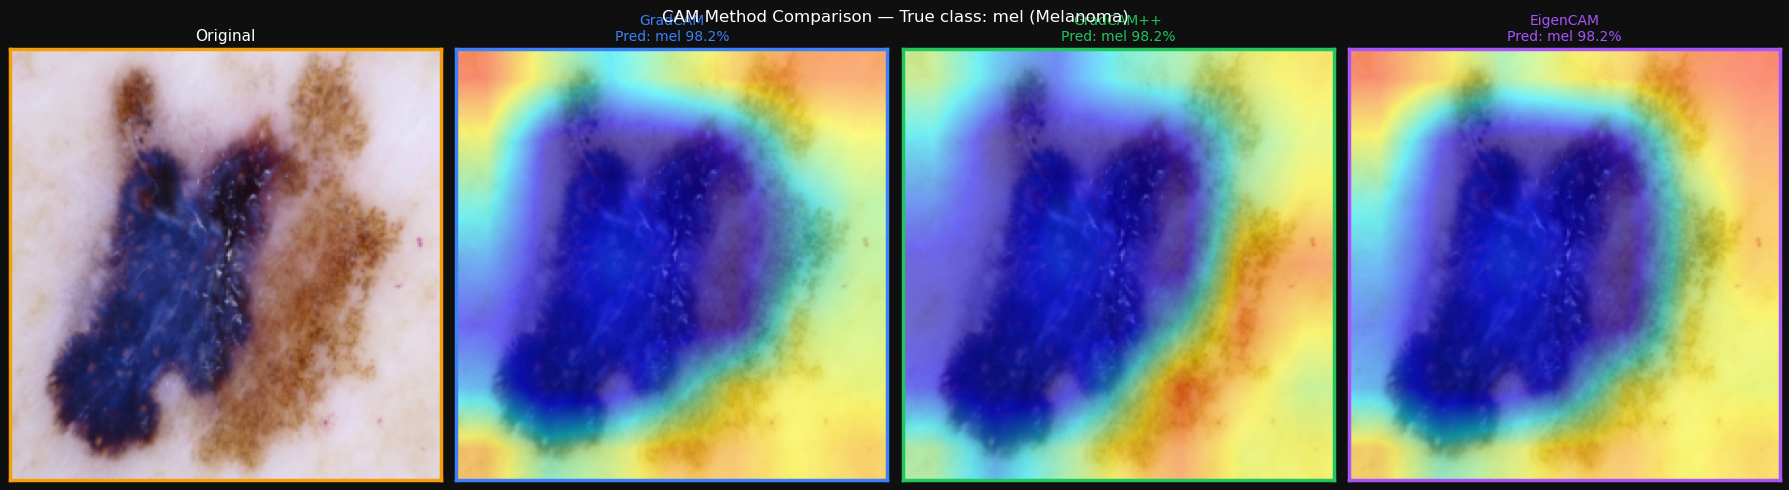


Look at the 3 heatmaps above.
Best method = the one where RED area sits clearly ON the lesion
(not scattered randomly across the image)

Typically GradCAM++ wins on medical images — verify visually.


In [7]:
# Pick one clear melanoma or bcc image for comparison
# (these classes tend to have the most visually distinct lesions)
for cls_target in ['mel', 'bcc', 'nv']:
    subset = test_df[IDX_TO_CLASS[test_df['label'].values] == cls_target 
                     if False else test_df['label'] == CLASS_TO_IDX[cls_target]]
    if len(subset) > 0:
        compare_path = subset.iloc[3]['img_path']  # 4th image, not 1st
        compare_cls  = cls_target
        break

print(f'Comparing CAM methods on: {Path(compare_path).name} (class: {compare_cls})')

methods = ['gradcam', 'gradcam++', 'eigencam']
results = {m: predict_and_gradcam(compare_path, cam_method=m) for m in methods}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f0f')
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

# Original
axes[0].imshow(results['gradcam']['original_rgb'])
axes[0].set_title('Original', color='white', fontsize=11)
for sp in axes[0].spines.values(): sp.set_edgecolor('#f59e0b'); sp.set_linewidth(2.5)

# Each method
method_labels = ['GradCAM', 'GradCAM++', 'EigenCAM']
colors = ['#3b82f6', '#22c55e', '#a855f7']
for i, (m, label, col) in enumerate(zip(methods, method_labels, colors)):
    r = results[m]
    axes[i+1].imshow(r['heatmap_rgb'])
    axes[i+1].set_title(
        f'{label}\nPred: {r["predicted_cls"]} {r["confidence"]:.1f}%',
        color=col, fontsize=10
    )
    for sp in axes[i+1].spines.values():
        sp.set_edgecolor(col); sp.set_linewidth(2.5)

fig.suptitle(
    f'CAM Method Comparison — True class: {compare_cls} '
    f'({class_info[compare_cls]["full"]})',
    color='white', fontsize=12
)
plt.tight_layout()
plt.savefig(GRADCAM_DIR / 'method_comparison.png', dpi=120,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print('\nLook at the 3 heatmaps above.')
print('Best method = the one where RED area sits clearly ON the lesion')
print('(not scattered randomly across the image)')
print('\nTypically GradCAM++ wins on medical images — verify visually.')

In [8]:
# Set this to whichever method looked best in Cell 6
BEST_METHOD = 'gradcam++'   # change to 'gradcam' or 'eigencam' if they looked better

SEVERITY_COLORS = {'LOW': '#22c55e', 'MEDIUM': '#f59e0b', 'HIGH': '#ef4444'}
classes = list(CLASS_TO_IDX.keys())

hero_candidates = []   # track images with correct predictions for hero selection
results_log     = []   # log all results

print(f'Generating heatmaps using {BEST_METHOD}...')
print(f'3 images per class × 7 classes = 21 images\n')

for cls in classes:
    cls_df  = test_df[test_df['label'] == CLASS_TO_IDX[cls]]
    n_imgs  = min(3, len(cls_df))        # 3 per class, or fewer if not enough
    samples = cls_df.sample(n=n_imgs, random_state=42)

    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = row['img_path']

        try:
            result = predict_and_gradcam(img_path, cam_method=BEST_METHOD)
        except Exception as e:
            print(f'  ⚠️  Error on {Path(img_path).name}: {e}')
            continue

        predicted = result['predicted_cls']
        correct   = predicted == cls
        conf      = result['confidence']
        sev_col   = SEVERITY_COLORS[result['severity']]

        # ── Save individual heatmap image ──
        fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
        fig.patch.set_facecolor('#0f0f0f')

        # Original
        axes[0].imshow(result['original_rgb'])
        axes[0].set_title('Original Image', color='white', fontsize=10)
        axes[0].set_xticks([]); axes[0].set_yticks([])

        # Heatmap overlay
        axes[1].imshow(result['heatmap_rgb'])
        axes[1].set_title('Grad-CAM Heatmap\n(लाल क्षेत्र = AI यहाँ देख रहा है)',
                          color='#22c55e', fontsize=10)
        axes[1].set_xticks([]); axes[1].set_yticks([])

        # Prediction panel
        axes[2].set_facecolor('#1a1a1a')
        axes[2].set_xticks([]); axes[2].set_yticks([])
        for sp in axes[2].spines.values(): sp.set_color('#333')

        y = 0.88
        axes[2].text(0.5, y, f'Prediction', transform=axes[2].transAxes,
                    ha='center', color='#888', fontsize=9)
        y -= 0.14
        axes[2].text(0.5, y, class_info[predicted]['full'],
                    transform=axes[2].transAxes, ha='center',
                    color='white', fontsize=11, fontweight='bold')
        y -= 0.12
        axes[2].text(0.5, y, class_info[predicted]['hindi'],
                    transform=axes[2].transAxes, ha='center',
                    color='#a3e8b8', fontsize=10)
        y -= 0.14
        axes[2].text(0.5, y, f'Confidence: {conf:.1f}%',
                    transform=axes[2].transAxes, ha='center',
                    color='white', fontsize=10)

        # Confidence bar
        y -= 0.10
        bar_w = conf / 100 * 0.7
        axes[2].add_patch(plt.Rectangle((0.15, y-0.03), 0.7, 0.06,
                         transform=axes[2].transAxes,
                         color='#333', zorder=1))
        axes[2].add_patch(plt.Rectangle((0.15, y-0.03), bar_w, 0.06,
                         transform=axes[2].transAxes,
                         color=sev_col, zorder=2))

        y -= 0.16
        axes[2].text(0.5, y, f'Severity: {result["severity"]}',
                    transform=axes[2].transAxes, ha='center',
                    color=sev_col, fontsize=11, fontweight='bold')
        y -= 0.16
        # Wrap next step text
        next_step = result['next_step']
        axes[2].text(0.5, y, next_step,
                    transform=axes[2].transAxes, ha='center',
                    color='#888', fontsize=8, wrap=True,
                    multialignment='center')

        if result['uncertain']:
            axes[2].text(0.5, 0.05, '⚠ अनिश्चित — डॉक्टर को दिखाएं',
                        transform=axes[2].transAxes, ha='center',
                        color='#f59e0b', fontsize=8)

        status = '✅ CORRECT' if correct else '❌ WRONG'
        border_col = '#22c55e' if correct else '#ef4444'
        for sp in axes[1].spines.values():
            sp.set_edgecolor(border_col); sp.set_linewidth(3)

        fig.suptitle(
            f'True: {cls} ({class_info[cls]["full"]})   {status}',
            color=border_col, fontsize=11
        )
        plt.tight_layout()

        save_name = f'{cls}_{i+1}_{"correct" if correct else "wrong"}.png'
        plt.savefig(GRADCAM_DIR / save_name, dpi=100,
                    bbox_inches='tight', facecolor='#0f0f0f')
        plt.close()

        log_entry = {
            'true_cls'  : cls,
            'pred_cls'  : predicted,
            'correct'   : correct,
            'confidence': conf,
            'uncertain' : result['uncertain'],
            'severity'  : result['severity'],
            'saved_as'  : save_name,
        }
        results_log.append(log_entry)

        if correct and conf > 70:
            hero_candidates.append(log_entry)

        status_icon = '✅' if correct else '❌'
        print(f'  {status_icon} {cls:6s} [{i+1}] → pred:{predicted:6s} '
              f'conf:{conf:5.1f}%  {"⚠️ uncertain" if result["uncertain"] else ""}')



Generating heatmaps using gradcam++...
3 images per class × 7 classes = 21 images

  ✅ nv     [1] → pred:nv     conf: 99.9%  
  ❌ nv     [2] → pred:bcc    conf: 88.7%  
  ❌ nv     [3] → pred:bcc    conf: 97.3%  
  ❌ mel    [1] → pred:nv     conf: 93.8%  
  ❌ mel    [2] → pred:bkl    conf: 35.5%  ⚠️ uncertain
  ❌ mel    [3] → pred:nv     conf: 68.6%  
  ❌ bkl    [1] → pred:mel    conf: 84.0%  
  ❌ bkl    [2] → pred:akiec  conf: 97.5%  
  ✅ bkl    [3] → pred:bkl    conf: 75.0%  
  ✅ bcc    [1] → pred:bcc    conf: 99.7%  
  ✅ bcc    [2] → pred:bcc    conf: 99.7%  
  ✅ bcc    [3] → pred:bcc    conf: 98.2%  
  ✅ akiec  [1] → pred:akiec  conf: 90.0%  
  ✅ akiec  [2] → pred:akiec  conf: 90.3%  
  ✅ akiec  [3] → pred:akiec  conf: 50.6%  ⚠️ uncertain
  ✅ vasc   [1] → pred:vasc   conf:100.0%  
  ✅ vasc   [2] → pred:vasc   conf: 98.9%  
  ✅ vasc   [3] → pred:vasc   conf: 99.7%  
  ✅ df     [1] → pred:df     conf: 97.7%  
  ❌ df     [2] → pred:nv     conf: 69.3%  
  ✅ df     [3] → pred:df     conf

In [9]:

hero_candidates.sort(key=lambda x: (
    x['severity'] == 'HIGH',    # HIGH severity first
    x['correct'],
    x['confidence']
), reverse=True)

print('🏆 TOP HERO CANDIDATES (for demo)')
print('=' * 60)
for i, h in enumerate(hero_candidates[:6]):
    print(f'  [{i+1}] {h["true_cls"]:6s} | conf:{h["confidence"]:5.1f}% '
          f'| sev:{h["severity"]:6s} | file: {h["saved_as"]}')

print()
print('Recommended picks for demo:')
if hero_candidates:
    high_sev = [h for h in hero_candidates if h['severity'] == 'HIGH']
    low_sev  = [h for h in hero_candidates if h['severity'] == 'LOW']
    med_sev  = [h for h in hero_candidates if h['severity'] == 'MEDIUM']

    picks = []
    if high_sev: picks.append(('Hero 1 (RED — urgent)', high_sev[0]))
    if low_sev:  picks.append(('Hero 2 (GREEN — safe)', low_sev[0]))
    if med_sev:  picks.append(('Hero 3 (AMBER — monitor)', med_sev[0]))

    for label, h in picks:
        print(f'  {label}: {h["saved_as"]} ({h["confidence"]:.1f}% confident)')



🏆 TOP HERO CANDIDATES (for demo)
  [1] bcc    | conf: 99.7% | sev:HIGH   | file: bcc_1_correct.png
  [2] bcc    | conf: 99.7% | sev:HIGH   | file: bcc_2_correct.png
  [3] bcc    | conf: 98.2% | sev:HIGH   | file: bcc_3_correct.png
  [4] vasc   | conf:100.0% | sev:MEDIUM | file: vasc_1_correct.png
  [5] nv     | conf: 99.9% | sev:LOW    | file: nv_1_correct.png
  [6] vasc   | conf: 99.7% | sev:MEDIUM | file: vasc_3_correct.png

Recommended picks for demo:
  Hero 1 (RED — urgent): bcc_1_correct.png (99.7% confident)
  Hero 2 (GREEN — safe): nv_1_correct.png (99.9% confident)
  Hero 3 (AMBER — monitor): vasc_1_correct.png (100.0% confident)

Open these files from outputs/gradcam/ and check visually.
The heatmap RED zone should sit clearly on the skin lesion.
If it looks scattered or random on any image, skip that image.


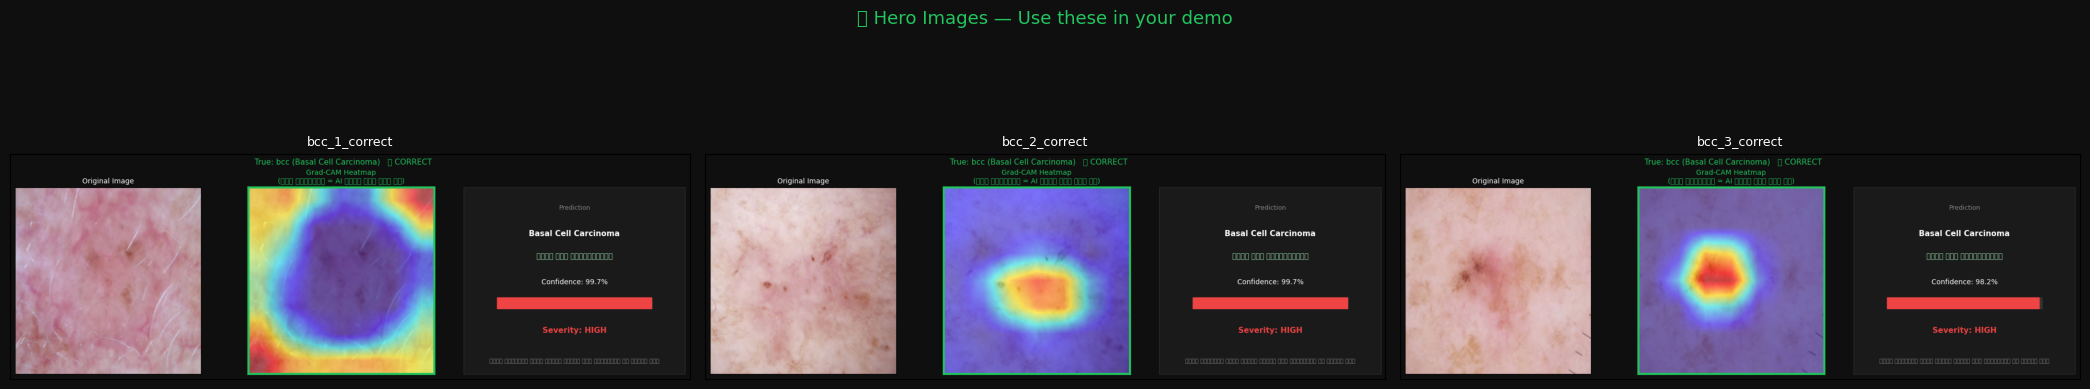

✅ Hero images saved to D:\rural diagnosis\rural_health_ai\outputs\gradcam\HERO_IMAGES.png


In [10]:
# Display the top 3 heroes side by side for quick visual check
hero_files = list(GRADCAM_DIR.glob('*.png'))
hero_files = [f for f in hero_files
              if 'correct' in f.name
              and 'smoke' not in f.name
              and 'method' not in f.name]

# Sort by class priority: mel, bcc, vasc, akiec, bkl, df, nv
priority = {'mel':0,'bcc':1,'vasc':2,'akiec':3,'bkl':4,'df':5,'nv':6}
hero_files.sort(key=lambda f: priority.get(f.name.split('_')[0], 9))

display_files = hero_files[:3]
if not display_files:
    print('No correct-prediction heatmaps found — displaying all generated images')
    display_files = list(GRADCAM_DIR.glob('*.png'))[:3]

fig, axes = plt.subplots(1, len(display_files),
                         figsize=(7 * len(display_files), 5))
fig.patch.set_facecolor('#0f0f0f')
if len(display_files) == 1:
    axes = [axes]

for ax, fpath in zip(axes, display_files):
    img = Image.open(fpath)
    ax.imshow(img)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(fpath.stem, color='white', fontsize=9)
    ax.set_facecolor('#0f0f0f')

fig.suptitle('🏆 Hero Images — Use these in your demo',
             color='#22c55e', fontsize=13)
plt.tight_layout()
plt.savefig(GRADCAM_DIR / 'HERO_IMAGES.png', dpi=120,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f'✅ Hero images saved to {GRADCAM_DIR / "HERO_IMAGES.png"}')

In [11]:
gradcam_fn_code = '''
"""
gradcam_fn.py — Rural Health AI
Reusable inference + Grad-CAM function for the FastAPI backend.
Person 2: import this file and call predict_and_gradcam(image_bytes)
"""
import json, io, base64, warnings
warnings.filterwarnings("ignore")

import numpy as np
import cv2
import torch
import torchvision.transforms as transforms
import timm
from PIL import Image
from pathlib import Path
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ── Paths (update if deploying elsewhere) ──
PROJECT_ROOT    = Path(__file__).parent.parent
BEST_MODEL_PATH = PROJECT_ROOT / "models" / "checkpoints" / "best_model.pth"
CLASS_INFO_PATH = PROJECT_ROOT / "data" / "class_info.json"
CONFIG_PATH     = PROJECT_ROOT / "data" / "config.json"

# ── Load once at import time ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(CONFIG_PATH) as f:
    cfg = json.load(f)
with open(CLASS_INFO_PATH, encoding="utf-8") as f:
    CLASS_INFO = json.load(f)["class_info"]

IDX_TO_CLASS = {int(k): v for k, v in cfg["idx_to_class"].items()}
CLASS_TO_IDX = cfg["class_to_idx"]

checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
_model = timm.create_model("efficientnet_b0", pretrained=False, num_classes=7)
_model.load_state_dict(checkpoint["model_state_dict"])
_model = _model.to(device)
_model.eval()

_target_layers = [_model.blocks[-1]]

_preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(cfg["imagenet_mean"], cfg["imagenet_std"]),
])

print(f"[gradcam_fn] Model loaded on {device} — val acc {checkpoint[\'val_acc\']*100:.2f}%")


def predict_and_gradcam(image_input):
    """
    Main function for FastAPI backend.

    Args:
        image_input: bytes | PIL.Image | str path

    Returns:
        dict with keys:
          top3          : list of {class, label, hindi, confidence, severity}
          predicted_cls : str
          confidence    : float (0-100)
          severity      : LOW | MEDIUM | HIGH
          next_step     : str (Hindi)
          uncertain     : bool
          heatmap_b64   : str (base64 PNG)
    """
    if isinstance(image_input, bytes):
        pil_img = Image.open(io.BytesIO(image_input)).convert("RGB")
    elif isinstance(image_input, (str, Path)):
        pil_img = Image.open(image_input).convert("RGB")
    else:
        pil_img = image_input.convert("RGB")

    input_tensor = _preprocess(pil_img).unsqueeze(0).to(device)

    # Denormalise for heatmap overlay
    mean = torch.tensor(cfg["imagenet_mean"]).view(3,1,1)
    std  = torch.tensor(cfg["imagenet_std"]).view(3,1,1)
    rgb_img = (input_tensor.squeeze(0).cpu() * std + mean).clamp(0,1)
    rgb_img = rgb_img.permute(1,2,0).numpy().astype(np.float32)

    _model.eval()
    with torch.no_grad():
        probs = _model(input_tensor).softmax(dim=1)[0]

    top3_vals, top3_idxs = probs.topk(3)
    top3 = []
    for val, idx in zip(top3_vals.cpu().numpy(), top3_idxs.cpu().numpy()):
        cls  = IDX_TO_CLASS[int(idx)]
        info = CLASS_INFO[cls]
        top3.append({
            "class"     : cls,
            "label"     : info["full"],
            "hindi"     : info["hindi"],
            "confidence": round(float(val) * 100, 1),
            "severity"  : info["severity"],
        })

    predicted_idx = int(top3_idxs[0].cpu())
    predicted_cls = IDX_TO_CLASS[predicted_idx]
    confidence    = top3[0]["confidence"]

    # Grad-CAM
    with GradCAMPlusPlus(model=_model, target_layers=_target_layers) as cam:
        grayscale = cam(
            input_tensor=input_tensor,
            targets=[ClassifierOutputTarget(predicted_idx)],
            aug_smooth=True,
            eigen_smooth=True,
        )[0]

    overlay = show_cam_on_image(
        rgb_img, grayscale,
        use_rgb=True,
        colormap=cv2.COLORMAP_JET,
        image_weight=0.5,
    )
    buf = io.BytesIO()
    Image.fromarray(overlay).save(buf, format="PNG")
    heatmap_b64 = base64.b64encode(buf.getvalue()).decode("utf-8")

    return {
        "top3"          : top3,
        "predicted_cls" : predicted_cls,
        "confidence"    : confidence,
        "severity"      : CLASS_INFO[predicted_cls]["severity"],
        "next_step"     : CLASS_INFO[predicted_cls]["next_step"],
        "uncertain"     : confidence < 60.0,
        "heatmap_b64"   : heatmap_b64,
    }
'''

# Save to backend folder
backend_dir = PROJECT_ROOT / 'app' / 'backend'
backend_dir.mkdir(parents=True, exist_ok=True)
out_path = backend_dir / 'gradcam_fn.py'

with open(out_path, 'w', encoding='utf-8') as f:
    f.write(gradcam_fn_code.strip())

print(f'✅ gradcam_fn.py saved to {out_path}')


✅ gradcam_fn.py saved to D:\rural diagnosis\rural_health_ai\app\backend\gradcam_fn.py

Person 2 (backend) can now do:
  from gradcam_fn import predict_and_gradcam
  result = predict_and_gradcam(image_bytes)

DAY 3 COMPLETE ✦

What you built:
  ✅ predict_and_gradcam() function — full pipeline
  ✅ 21 heatmap images saved (3 per class)
  ✅ Hero images identified for demo
  ✅ gradcam_fn.py ready for Person 2 to import

Tomorrow (Day 4): ONNX export + INT8 quantization
Goal: model_quantized.onnx < 15MB, runs in browser offline


Correct prediction heatmaps: 13
  akiec_1_correct.png
  akiec_2_correct.png
  akiec_3_correct.png
  bcc_1_correct.png
  bcc_2_correct.png
  bcc_3_correct.png
  bkl_3_correct.png
  df_1_correct.png
  df_3_correct.png
  nv_1_correct.png
  vasc_1_correct.png
  vasc_2_correct.png
  vasc_3_correct.png


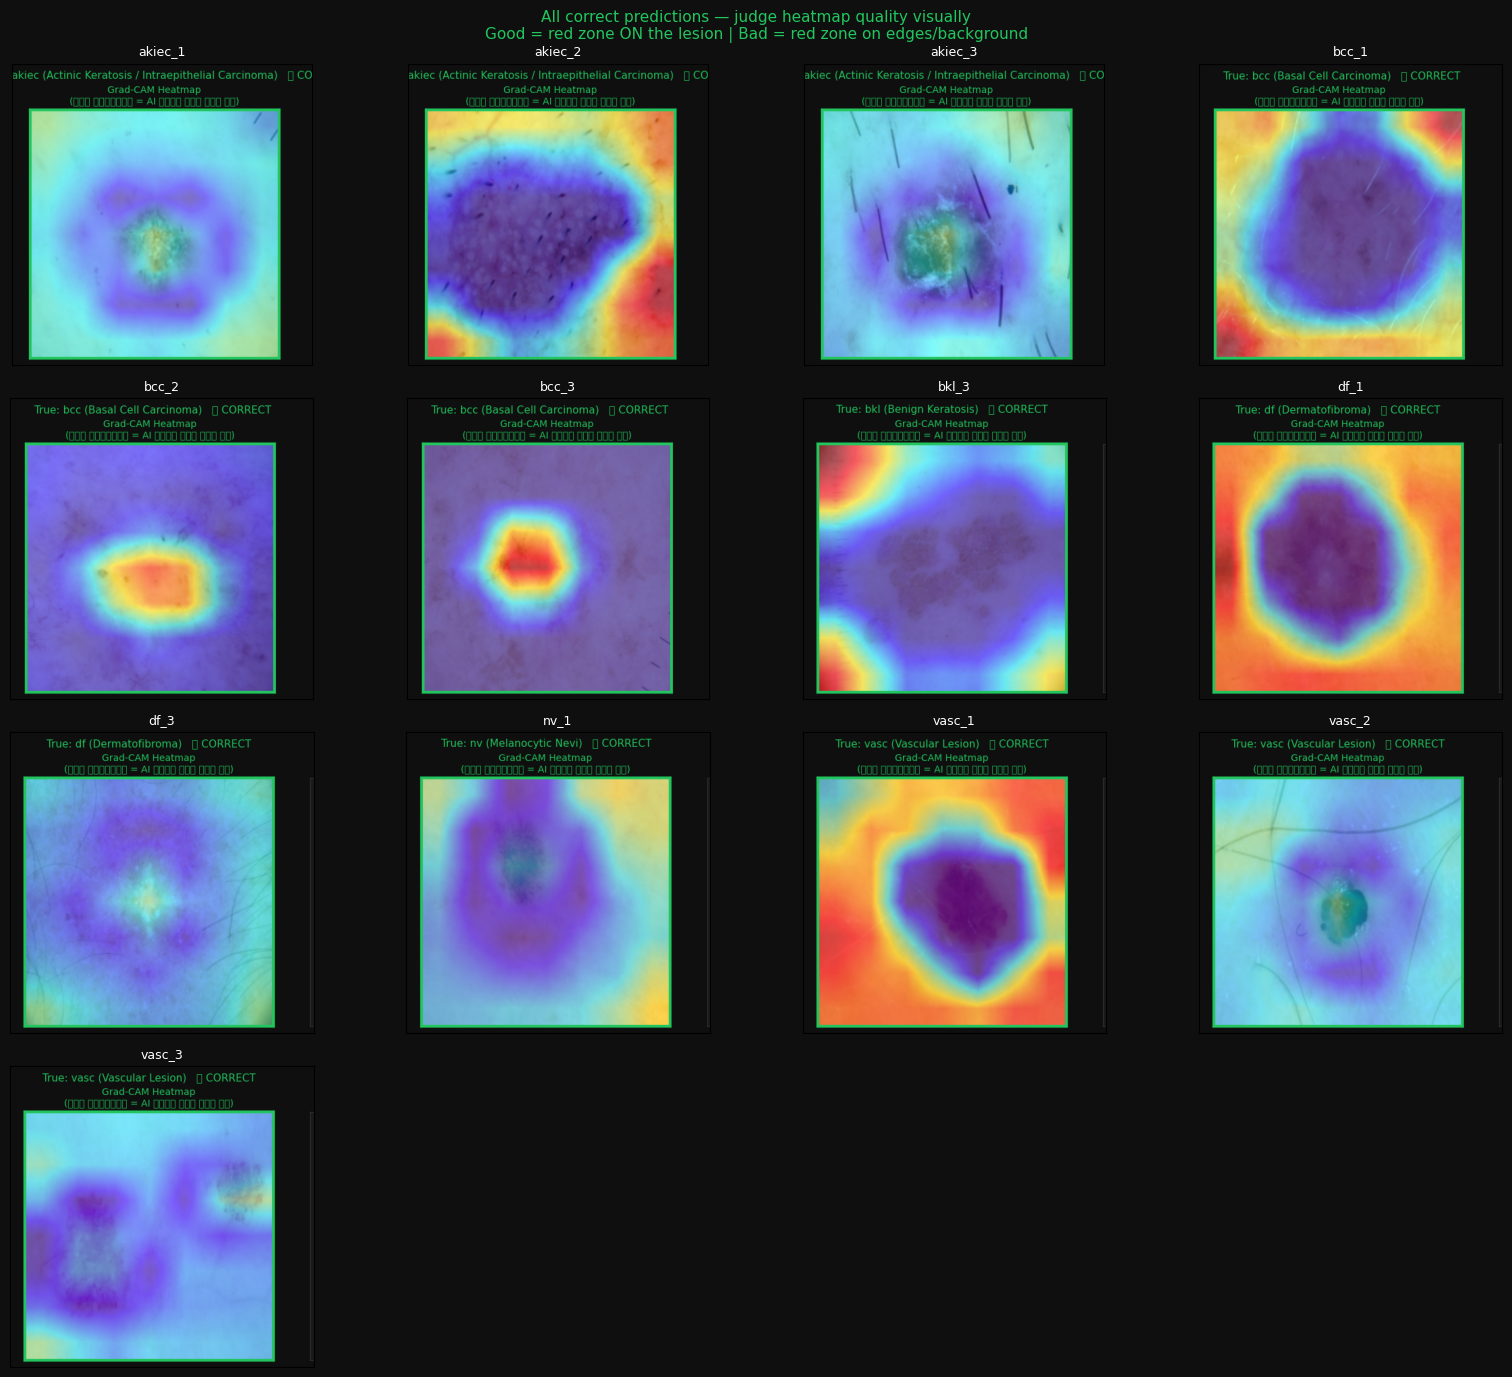

Saved → all_correct_heatmaps.png


In [1]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

GRADCAM_DIR  = Path(r"D:\rural diagnosis\rural_health_ai\outputs\gradcam")

# Get all correct prediction files, excluding smoke test and comparison
correct_files = sorted([
    f for f in GRADCAM_DIR.glob('*.png')
    if 'correct' in f.name
    and 'smoke'  not in f.name
    and 'method' not in f.name
    and 'HERO'   not in f.name
])

print(f'Correct prediction heatmaps: {len(correct_files)}')
for f in correct_files:
    print(f'  {f.name}')

# Display them all in a grid so you can visually judge each one
n = len(correct_files)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
fig.patch.set_facecolor('#0f0f0f')
axes = axes.flatten() if rows > 1 else axes

for i, (ax, fpath) in enumerate(zip(axes, correct_files)):
    # Load and show only the heatmap panel (middle third of the saved image)
    img = Image.open(fpath)
    w, h = img.size
    # Each saved image is 3 panels wide — crop to middle panel (heatmap)
    heatmap_panel = img.crop((w//3, 0, 2*w//3, h))
    ax.imshow(heatmap_panel)
    ax.set_title(fpath.stem.replace('_correct',''),
                 color='white', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_facecolor('#0f0f0f')

# Hide unused axes
for ax in axes[len(correct_files):]:
    ax.set_visible(False)

fig.suptitle('All correct predictions — judge heatmap quality visually\n'
             'Good = red zone ON the lesion | Bad = red zone on edges/background',
             color='#22c55e', fontsize=11)
plt.tight_layout()
plt.savefig(GRADCAM_DIR / 'all_correct_heatmaps.png',
            dpi=100, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Saved → all_correct_heatmaps.png')
